In [ ]:
from rtrv_models.cscg import CSCG
from rtrv_models.data.graph import MazeEnv, maze1_graph, check_relation, CP_DSP1, maze2_graph, get_metric
from rtrv_models.data.preprocess import PreprocessedData, preprocess_data
import numpy as np
from rtrv_models.data._io import load_data, SAVE_DIR
import pandas as pd
import os
import pickle

DSPPalette = ["#A9CCE3", "#82C3C5", '#9C8FBC', "#D9A6A9", "#DCC8A4", '#647D91', "#C06C84"]

maze1 = MazeEnv(maze1_graph)
obs_counts1 = np.histogram(maze1.obs, range=(-0.5, 5.5), bins=6)
print(obs_counts1)
maze2 = MazeEnv(maze2_graph)
obs_counts2 = np.histogram(maze2.obs, range=(-0.5, 5.5), bins=6)
print(obs_counts2)

n_clones = (np.mean(np.vstack([obs_counts1[0], obs_counts2[0]]), axis=0) * 4).astype(np.int64)
print(n_clones)


for mouse in [10212, 10224, 10227, 10232]:
    print(f"Processing mouse {mouse}")
    if os.path.exists(os.path.join(SAVE_DIR, f" cscg_{mouse}.pkl")):
        print("  Existed, skip.")
        continue

    res: PreprocessedData = preprocess_data(mouse)
    x = res.obs_train
    a = res.all_act_train
    beg_train, end_train = res.get_lap_dur_train()

    n_obs = 6
    pseudocount = 1e-5
    n_iters = 100

    cscg = CSCG(n_clones=n_clones, act=a, obs=x, pseudocount=pseudocount)  # Initialize the model
    cscg.fit_by_trial(trial_beg=beg_train, trial_end=end_train, n_iter=n_iters)
    with open(os.path.join(SAVE_DIR, f"cscg_{mouse}.pkl"), "wb") as f:
        pickle.dump(cscg, f)
        
    x_ego = res.obs_train
    a_ego = res.ego_act_train
    
    cscg_ego = CSCG(n_clones=n_clones, act=a_ego, obs=x_ego, pseudocount=pseudocount)
    cscg_ego.fit_by_trial(trial_beg=beg_train, trial_end=end_train, n_iter=n_iters)
    with open(os.path.join(SAVE_DIR, f"cscg_{mouse}_ego.pkl"), "wb") as f:
        pickle.dump(cscg_ego, f)

(array([ 1, 17, 35, 74, 16,  1]), array([-0.5,  0.5,  1.5,  2.5,  3.5,  4.5,  5.5]))
(array([ 1, 19, 34, 71, 18,  1]), array([-0.5,  0.5,  1.5,  2.5,  3.5,  4.5,  5.5]))
[  4  72 138 290  68   4]
Processing mouse 10212
Average number of clones: 96.0
Processing trial 0


  0%|          | 0/100 [00:00<?, ?it/s]

# Test Retrieval W/O Plasticity

Average number of clones: 96.0


100%|██████████| 1/1 [00:35<00:00, 35.46s/it, train_bps=1.75]


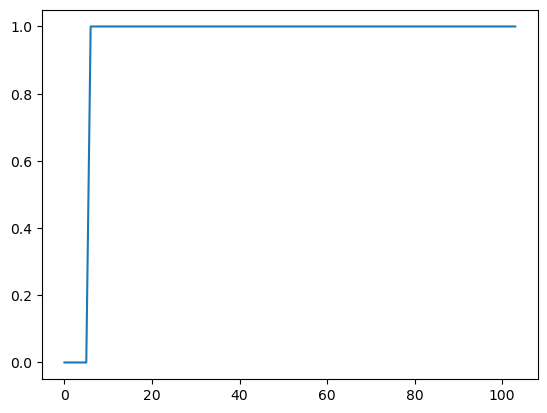

775it [00:04, 176.41it/s]


In [11]:
import matplotlib.pyplot as plt
import pickle
import seaborn as sns
from tqdm import tqdm

mouse = 10232
D1 = get_metric(1)
with open(os.path.join(SAVE_DIR, f"cscg_{mouse}.pkl"), 'rb') as f:
    chmm: CSCG = pickle.load(f)


        
res: PreprocessedData = preprocess_data(mouse)
x = res.obs_train
a = res.all_act_train
beg_train, end_train = res.get_lap_dur_train()
x_test = res.obs_test
a_test = res.all_act_test
p_test = res.pos_test
r_test = res.route_test

n_obs = 6
pseudocount = 1e-5
n_iter = 1
cscg = CSCG(n_clones=n_clones, act=a, obs=x, pseudocount=pseudocount)  # Initialize the model
cscg.fit(n_iter=n_iter)
chmm = cscg
#with open(os.path.join(SAVE_DIR, f"cscg_{mouse}_trained_together.pkl"), "rb") as f:
#    chmm: CSCG = pickle.load(f)

a_perf, x_perf = res.get_ideal_seq(rt=0, mode='all')

a_perf_rt, x_perf_rt = res.get_ideal_seq(rt=4, mode='all')
p_perf_rt = CP_DSP1[4]

hidden_state_rt = chmm.model.decode(x_perf_rt, a_perf_rt)[1]
hidden_state_0 = chmm.model.decode(x_perf, a_perf)[1]
is_retrieval = np.where(hidden_state_0[-CP_DSP1[4].shape[0]:] - hidden_state_rt == 0, 1, 0)
plt.plot(is_retrieval)
plt.show()

state_perf = np.zeros(144)
state_perf[CP_DSP1[0]-1] = chmm.predict(x_perf, a_perf)


beg, end = res.get_lap_dur_test()
is_retrieval = np.zeros(len(x_test))
for b, e in tqdm(zip(beg, end)):
    state_pred = chmm.model.decode(x_test[b:e], a_test[b:e])[1]
    state_test = state_perf[p_test[b:e]-1]    
    is_retrieval[b:e] = np.where(state_test-state_pred==0, 1, 0)
    
x = D1[p_test-1, 0]
idx = np.where(np.isin(p_test, CP_DSP1[0]))[0]

data = {
    "is_retrieval": is_retrieval[idx],
    "Pos": x[idx],
    "Route": r_test[idx]
}

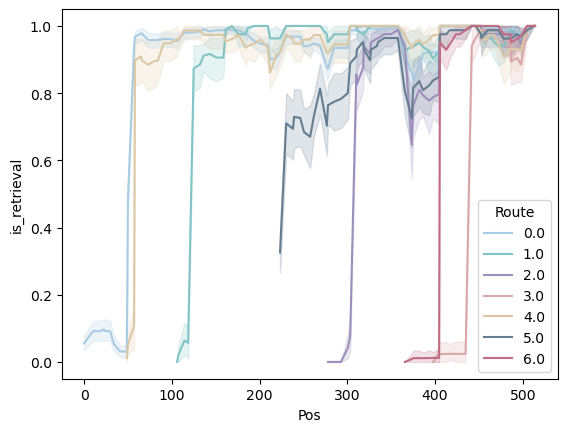

In [12]:
fig = plt.figure()
ax = plt.axes()
sns.lineplot(x="Pos", y="is_retrieval", hue="Route", palette=DSPPalette, data=data, ax=ax)
plt.show()

# Step-wise Retrieval

In [ ]:
import copy as cp

chmm3 = cp.deepcopy(chmm2)
for i in range(len(x_test)):
    chmm3.learn_em_T(x_test[:i+1], a_test[i:i+1], n_iter=100, term_early=False)
state = chmm3.decode(x_test, a_test)[1]

 37%|███▋      | 37/100 [00:00<00:00, 119.30it/s, train_bps=0.162]

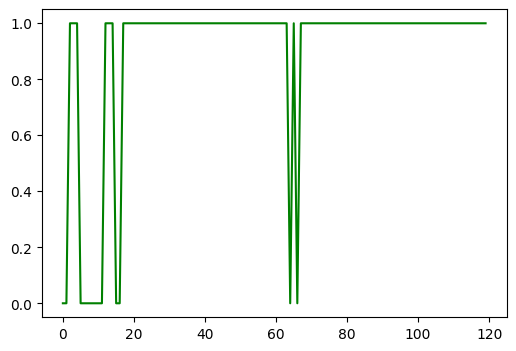

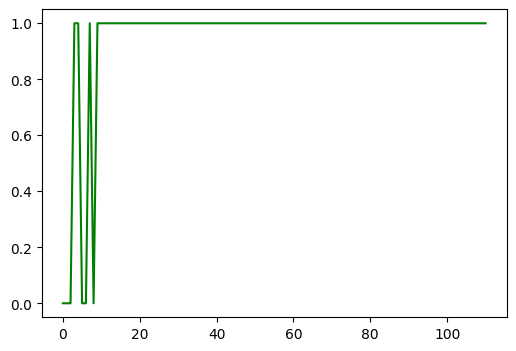

In [33]:
is_retrieve = np.zeros_like(state, dtype=np.int64)
for i in range(1, len(state)):
    node_i = res_test['Nodes'][i]-1
    try:
        idx = np.where(CP_DSP1[0]-1 == node_i)[0][0]
    except:
        continue
    
    retrieved_state = state_perf[idx]
    real_state = state[i]
    if retrieved_state == real_state:
        is_retrieve[i] = 1
        
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111)
ax.plot(np.arange(len(state)), is_retrieve, label="Is Retrieve", color="green")
plt.show()

state_perf2 = chmm3.decode(x_perf, a_perf)[1]

is_retrieve = np.where(state_perf2 - state_perf == 0, 1, 0)
        
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111)
ax.plot(np.arange(len(state_perf2)), is_retrieve, label="Is Retrieve", color="green")
plt.show()